# K-means clustering (another dataset)

As you might have noticed, there is another dataset in the data directory called `ML-ratings.csv`. This data comes from MovieLens and is a small subset of the data used in our manual. 

Can you cluster this data using the same methods as seen before (notebook 3)?  Is the clustering better than our books dataset or not?

In [1]:
import pandas as pd
df_ml_ratings = pd.read_csv('data/ML-ratings.csv', sep=',')
df_ml_ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [6]:
# First, we cluster movies by user ratings

from scipy.sparse import csr_matrix

ratings_matrix = df_ml_ratings.pivot(index='movieId', columns='userId', values='rating').fillna(0)
sparse_matrix = csr_matrix(ratings_matrix.values)

In [21]:
#  Make clusters

from sklearn.cluster import KMeans

kmeans_3_clusters = KMeans(n_clusters=5)
movie_clusters = kmeans_3_clusters.fit(sparse_matrix)

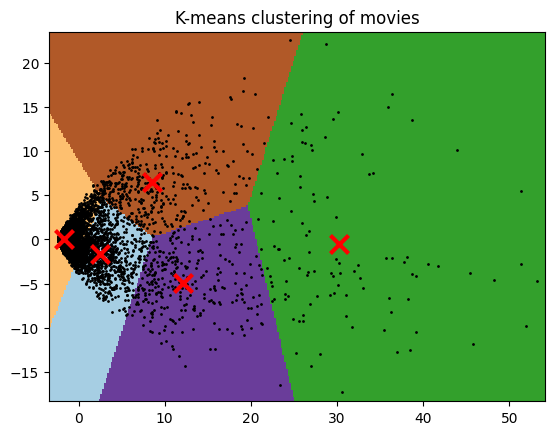

In [13]:
# This is the same visualisation function used in notebook 3.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot(user_ratings: csr_matrix, k: int):

        h = 0.2
        reduced_data = PCA(n_components=2).fit_transform(user_ratings)

        kmeans = KMeans(init='k-means++', n_clusters=k, n_init=10)
        kmeans.fit(reduced_data)

        x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
        y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

        Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

        # Put the result into a color plot
        Z = Z.reshape(xx.shape)

        plt.figure(1)
        plt.clf()
        plt.imshow(Z, interpolation='nearest',
                   extent=(xx.min(), xx.max(), yy.min(), yy.max()),
                   cmap=plt.cm.Paired,
                   aspect='auto', origin='lower')

        centroids = kmeans.cluster_centers_
        plt.plot(reduced_data[:, 0], reduced_data[:, 1], 'k.', markersize=2)
        plt.scatter(centroids[:, 0], centroids[:, 1],
                    marker='x', s=169, linewidths=3,
                    color='r', zorder=10)
        plt.title('K-means clustering of movies')

plot(sparse_matrix, 5)

In [16]:
# We can also cluster users

from scipy.sparse import csr_matrix

user_ratings_matrix = df_ml_ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)
users_sparse_matrix = csr_matrix(ratings_matrix.values)

In [19]:
kmeans_5_users_clusters = KMeans(n_clusters=5)
user_clusters = kmeans_3_clusters.fit(sparse_matrix)

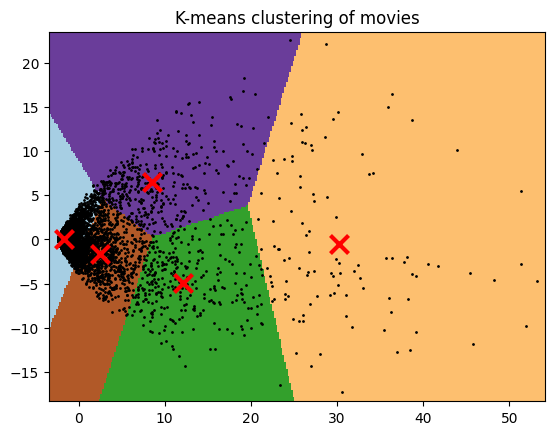

In [17]:
plot(users_sparse_matrix, 5)